<div style='text-align: center;'>
    <h2>Linnerud Dataset Analysis</h2><br>
    <strong>Hinako Samson</strong><br>
</div>

---

### Introduction

The Linnerud dataset consists of data on physical attributes and exercise performance. It is one of the datasets in Scikit Learn, and there are 20 instances, three attributes, and no missing values. 


### Discovery

Using the Linnerud dataset, we can analyze the relationship between physical attributes and exercise performance. Additionally, we can build predictive models to estimate exercise performance based on the given data.

First, we explore the dataset to understand its structure and contents.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor


# Load the Linnerud dataset
linnerud = load_linnerud()
X = pd.DataFrame(linnerud.data, columns=linnerud.feature_names)  # Exercise data
y = pd.DataFrame(linnerud.target, columns=linnerud.target_names)  # Physiological data

# Print dataset description
print(linnerud.DESCR)

# Access features and target
e = linnerud.data  # Exercise data
p = linnerud.target  # Physiological data

# Print shape of data
print("Feature Data Shape:", e.shape)
print("Target Data Shape:", p.shape)

print(e_linnerud_df.head())
print(p_linnerud_df.head())

Explore the dataset through visualizations. I created a histogram, a scattter plot, and a heatmap. 

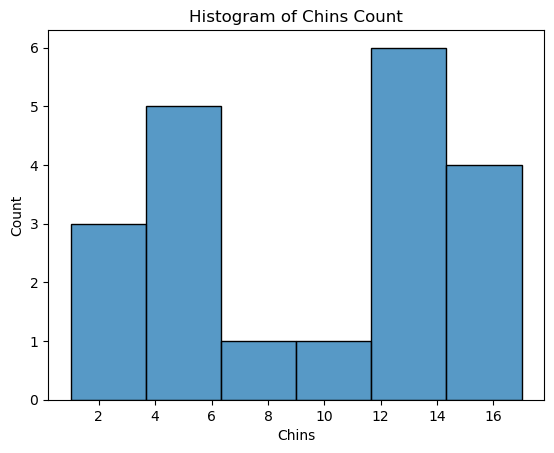

In [288]:
# Histogram
sns.histplot(e_linnerud_df['Chins']).set_title('Histogram of Chins Count')
plt.show()

The count for chins exercise is not evenly spread. Between 12 and 14 is the most common count and between 7 and 11 has the least count.

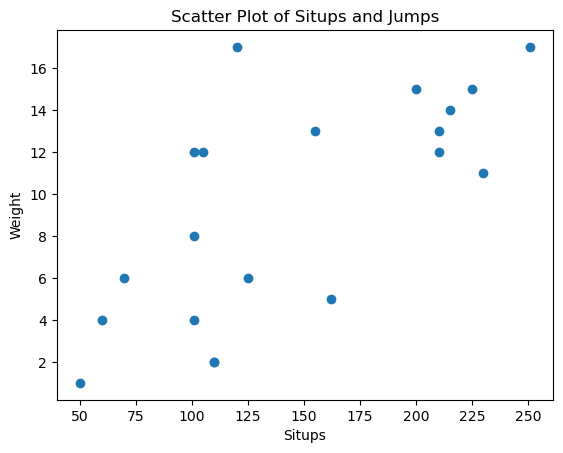

In [290]:
plt.scatter(e_linnerud_df.Situps, p_linnerud_df.Weight)
plt.xlabel('Situps')
plt.ylabel('Weight')
plt.title('Scatter Plot of Situps and Jumps')
plt.show()

The scatter plot illustrates the correlation between weight and sit-up count. It reveals that individuals with higher weight tend to perform more sit-ups, while those with lower weight perform fewer sit-ups.

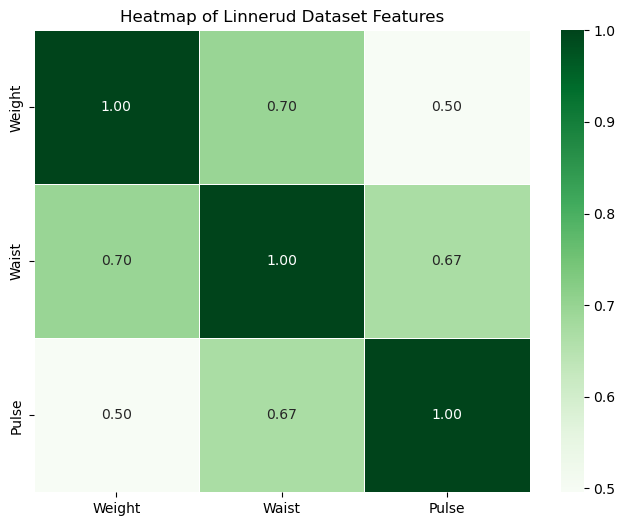

In [292]:
# Compute the correlation matrix
corr_matrix = p_linnerud_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Greens', fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Linnerud Dataset Features")
plt.show()

Pulse and waist show a stronger correlation than pulse and weight. The strongest correlation is observed between weight and waist.

### Data Preparation

According to Scikit-Learn, the dataset has no missing values. However, it is important to check for duplicate rows. I used `df.duplicated()` from pandas to identify any duplicates.

In [295]:
#data cleaning checking for duplicates
duplicates = df[df.duplicated()]
print("Duplicate Rows:\n", duplicates)

Duplicate Rows:
 Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Index: []


This data frame has no duplicate rows. 

### Model Planning

I chose multivariate regression for one of the models because the Linnerud dataset has two sets of data: physical attributes and exercise attributes. 

In [298]:
# Multivariate Regression
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Multivariate Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')

# Print results
print("Model Coefficients:\n", model.coef_)
print("\nModel Intercept:\n", model.intercept_)
print("\nMean Squared Error for each target variable:\n", mse)

Model Coefficients:
 [[ 0.45032944 -0.31848005  0.09103322]
 [-0.07820805 -0.04851095  0.02797324]
 [-0.48276697  0.09321505 -0.05008643]]

Model Intercept:
 [210.17957378  40.92073283  52.01086926]

Mean Squared Error for each target variable:
 [630.77570979   4.57089582  82.11441002]


Model coefficients' columns are weight, height, and waist (top to bottom). The rows are Chins, situps, and jumps (left to right). 
From the model coefficients, we can see that heavier individuals tend to do more chin-ups, while height negatively impacts performance. Coefficients for situps are small meaning physical attributes have minimal effects on the count for situps. Weight has a strong negative effect on jumps, which means heavier people were able to do fewer jumps. 

Mean Squared Errors show chins and jumps have weak accuracy and strong accuracy on situps. 

### Model Building

I created scatter plots for both the training and testing data to evaluate the model's accuracy. Both sets exhibit the same trend, and the Polynomial Regression line closely aligns with the scatter plots, indicating a good fit.

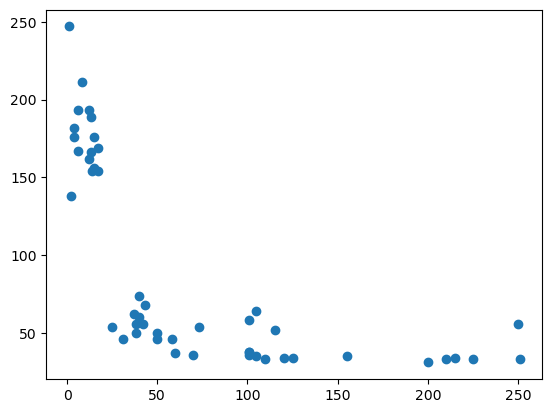

In [301]:
#train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
plt.scatter(X_train, y_train)
plt.show()

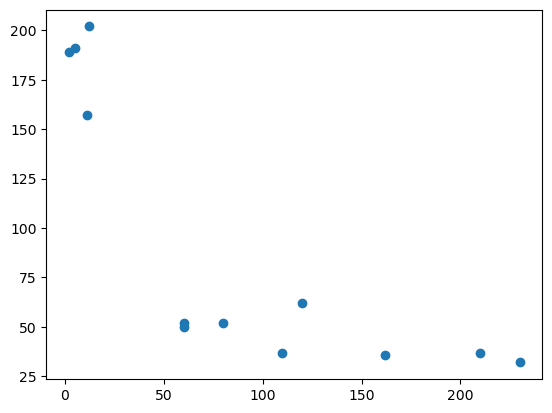

In [302]:
#test
plt.scatter(X_test, y_test)
plt.show()

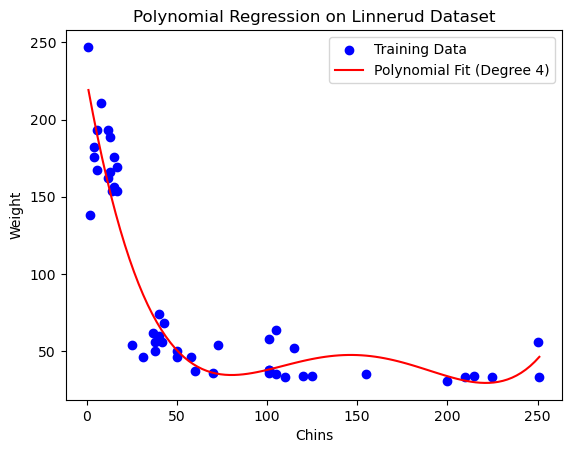

In [308]:
# Flatten the X_train and y_train arrays to 1D
X_train_flat = X_train.values.flatten()  # Convert to NumPy array and flatten
y_train_flat = y_train.values.flatten()  # Convert to NumPy array and flatten

# Fit a 4th-degree polynomial regression model
poly_coeffs = np.polyfit(X_train_flat, y_train_flat, 4)  # Fit polynomial of degree 4
poly_model = np.poly1d(poly_coeffs)  # Create a polynomial function

# Generate values for plotting the polynomial curve
x_range = np.linspace(min(X_train_flat), max(X_train_flat), 100)  # Generate x values
y_pred = poly_model(x_range)  # Predict y values

# Plot data and polynomial curve
plt.scatter(X_train_flat, y_train_flat, color='blue', label="Training Data")
plt.plot(x_range, y_pred, color='red', label="Polynomial Fit (Degree 4)")
plt.xlabel("Chins")
plt.ylabel("Weight")
plt.legend()
plt.title("Polynomial Regression on Linnerud Dataset")
plt.show()

##### Results
I calculated the Mean Squared Error for each target variable, and it shows that the situp count has the best accuracy (9.25) while the chin-up count has a weak accuracy (997.5).
I also performed a decision tree to capture relationships between physical attributes and exercise performance.

In the real world, it makes sense that heavier individuals are not necessarily more capable of chin-ups. They could be heavy due to muscle mass or because they are obese. It is difficult to know people's athletic ability by weight. 

In [ ]:
# Decision Tree
# Create and train the Decision Tree Regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Predict on the test set
y_pred = tree_model.predict(X_test)

# Evaluate the model using Mean Squared Error
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')

# Print results
print("Mean Squared Error for each target variable:\n", mse)


plt.figure(figsize=(30, 15))
plot_tree(tree_model, feature_names=linnerud.feature_names, filled=True)
plt.show()

In [ ]:
y_test_weight = y_test['Weight']
y_pred_weight = model.predict(X_test)[:, 0]  # Predict values for 'Weight'

# Plot the boxplot for the true vs predicted values for 'Weight'
plt.figure(figsize=(10, 6))
sns.boxplot(data=[y_test_weight, y_pred_weight], width=0.5)
plt.xticks([0, 1], ['True Values', 'Predicted Values'])
plt.title('Box Plot of True vs Predicted Values for Weight')
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

# Compute learning curves
train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=5)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation score')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

### Operationalization

This model can be used for weight loss training. It is important to increase the exercise level gradually, and this model can help set goals that are realistic to the person's ability.  

The main challenge is with the physical attributes, like weight. For example, two people who weigh the same, one who is obese and the other who is fit, will likely have very different exercise scores. This can confuse the model because weight alone doesn't show the full picture of a person’s fitness level (it doesn’t account for things like muscle mass or body fat). This can make the model less accurate.

### References

GeeksforGeeks. (2024, May 6). Linnerud Dataset Explain, Implementation, Application. GeeksforGeeks. https://www.geeksforgeeks.org/linnerrud-dataset/

Scikit Learn. (n.d.). 7.1. Toy datasets. Scikit-Learn. https://scikit-learn.org/stable/datasets/toy_dataset.html

Tsai, E. (2022, January 17). Add data labels in a scatter plot using Python Matplotlib | Eugene Tsai. Medium; Medium. https://medium.com/@marvelouskgc/three-ways-to-add-labels-to-each-data-point-in-a-scatter-plot-in-python-matplotlib-eugene-tsai-42e4094dc07e

W3Schools. (n.d.-a). Pandas DataFrame duplicated() Method. Www.w3schools.com. https://www.w3schools.com/python/pandas/ref_df_duplicated.asp

W3Schools. (n.d.-b). Python Machine Learning Decision Tree. Www.w3schools.com. https://www.w3schools.com/python/python_ml_decision_tree.asp

W3Schools. (n.d.-c). Python Machine Learning Train/Test. Www.w3schools.com. https://www.w3schools.com/python/python_ml_train_test.asp